# 0  

#### Che cosa è SLM_ANN  
Una rete neurale artificiale che opera "come se" fosse un piccolo modello linguistico, quindi Small Language Model, **SLM**  
#### Come si usa

Con clic su ![](https://terna.to.it/SLM_ANN/binder.png) in alto verso destra; attendendo qualche minuto, il programma diviene funzionante su un computer remoto. Con clic su ![](https://terna.to.it/SLM_ANN/esecuzione.png) il progamma va in esecuzione.  

#### Che prove si possono fare  

Nella casella **3**, se si sostituisce *False* con *True* e si fa clic su ![](https://terna.to.it/SLM_ANN/esecuzioneSpecifica.png) si ottiene il voluminoso output dei parametri del modello.  

Nella casella **5** si possono sostituire i termini in input, prima di tutto seguendo le frasi riportate qui sotto e poi provando a disporre in modo capriccioso le parole e gli spazi. Per eseguire la sola cella 5, in cui si sta lavorando, fare clic su ![](https://terna.to.it/SLM_ANN/esecuzioneSpecifica.png)

Se si usa un termine non compreso nelle frasi riportate, la parola errata è riportata e l'esecuzione si arresta.

===================================================================================================================

Provare a cambiare il valore H nella casella 1 e rieseguire con un numero di nodi nascosti diverso.

  
-----------------------------    
casistica, con **>** che separa l'input dall'output.


il,gatto,mangia,>,il,topo  
il,gatto, ,>,miagola,  
il,cane,mangia,>,il,gatto  
il,cane, ,>,abbaia,  
il,topo,mangia,>,il,formaggio  
il,bimbo,chiama,>,la,mamma  
il,bimbo,mangia,>,la,pappa  
il,bimbo, ,>,piange,  
bimbo,e,gatto,>,giocano,  

# 1
#### dizionari di servizio e numero di nodi nascosti H e funzione per disegnare gli istogrammi

In [1]:
H = 10


dictionary = \
 {' ': 0, 'il': 1, 'gatto': 2, 'mangia': 3, 'topo': 4, 'miagola': 5, 'cane': 6, 'abbaia': 7, 'formaggio': 8, 'bimbo': 9, 
  'chiama': 10, 'la': 11, 'mamma': 12, 'pappa': 13, 'piange': 14, 'e': 15, 'giocano': 16}
reverseDictionary= \
{0: ' ', 1: 'il', 2: 'gatto', 3: 'mangia', 4: 'topo', 5: 'miagola', 6: 'cane', 7: 'abbaia', 8: 'formaggio', 9: 'bimbo', 
 10: 'chiama', 11: 'la', 12: 'mamma', 13: 'pappa', 14: 'piange', 15: 'e', 16: 'giocano'}

# parole in ordine di dizionario (0..16)
words = [reverseDictionary[i] for i in range(len(reverseDictionary))]



def plot_in_out_histograms(inExp, test_outputs, words=None):
    import numpy as np
    import matplotlib.pyplot as plt
    
    # --- words (dictionary order) ---
    if words is None:
        if 'words' in globals():
            words = globals()['words']
        elif 'reverseDictionary' in globals():
            words = [reverseDictionary[i] for i in range(len(reverseDictionary))]
        else:
            # fallback: numeric labels
            words = [str(i) for i in range(17)]
    
    # --- INPUT: accept either (51,) flat or (17,3) ---
    inExp = np.array(inExp)
    if inExp.ndim == 1 and inExp.size == 17 * 3:
        inExp = inExp.reshape(3, 17).T   # (17,3) slots
    elif inExp.shape == (17, 3):
        pass
    else:
        raise ValueError(f"inExp shape inattesa: {inExp.shape}. Atteso (51,) oppure (17,3).")
    
    # --- OUTPUT: accept either (34,) flat or (17,2) ---
    test_outputs = np.array(test_outputs)
    if test_outputs.ndim == 1 and test_outputs.size == 17 * 2:
        test_outputs = test_outputs.reshape(2, 17).T  # (17,2)
    elif test_outputs.shape == (17, 2):
        pass
    else:
        raise ValueError(f"test_outputs shape inattesa: {test_outputs.shape}. Atteso (34,) oppure (17,2).")
    
    # --- INPUT HISTOGRAM (3 slots, colored) ---
    slot1 = inExp[:, 0]
    slot2 = inExp[:, 1]
    slot3 = inExp[:, 2]
    
    x = np.arange(len(words))
    width = 0.25
    
    plt.figure(figsize=(12, 5))
    plt.bar(x - width, slot1, width=width, label='Slot 1', color='tab:blue')
    plt.bar(x,         slot2, width=width, label='Slot 2', color='tab:orange')
    plt.bar(x + width, slot3, width=width, label='Slot 3', color='tab:green')
    
    plt.xticks(x, words, rotation=90)
    plt.title("Input histogram (3 slots)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # --- OUTPUT HISTOGRAM ---
    out1 = test_outputs[:, 0]
    out2 = test_outputs[:, 1]
    
    x = np.arange(len(words))
    width = 0.35
    
    plt.figure(figsize=(12, 5))
    plt.bar(x - width / 2, out1, width=width, label='Output 1')
    plt.bar(x + width / 2, out2, width=width, label='Output 2')
    
    plt.xticks(x, words, rotation=90)
    plt.title("Output histogram")
    plt.legend()
    plt.tight_layout()
    plt.show()


# 2  

In [2]:
# preparato da Copilot via WhatsApp
import numpy as np
import csv

# Sigmoid activation function and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# ANN parameters
input_nodes = 17*3
hidden_nodes = H
output_nodes = 17*2
learning_rate = 0.5
epochs = 10000

# Initialize weights randomly
np.random.seed(42)
weights_input_hidden = np.random.rand(hidden_nodes, input_nodes + 1) - 0.5  # +1 for bias
weights_hidden_output = np.random.rand(output_nodes, hidden_nodes + 1) - 0.5  # +1 for bias

# Training phase
def train(inputs, expected_output):
    global weights_input_hidden, weights_hidden_output
    
    inputs_with_bias = np.append(inputs, 1)  # Add bias to inputs
    hidden_inputs = np.dot(weights_input_hidden, inputs_with_bias)
    hidden_outputs = sigmoid(hidden_inputs)
    
    hidden_outputs_with_bias = np.append(hidden_outputs, 1)  # Add bias to hidden outputs
    final_inputs = np.dot(weights_hidden_output, hidden_outputs_with_bias)
    final_outputs = sigmoid(final_inputs)
    
    # Error calculation
    output_error = expected_output - final_outputs
    hidden_error = np.dot(weights_hidden_output[:, :-1].T, output_error) * sigmoid_derivative(hidden_outputs)

    # Update weights
    weights_hidden_output += learning_rate * np.outer(output_error * sigmoid_derivative(final_outputs), hidden_outputs_with_bias)
    weights_input_hidden += learning_rate * np.outer(hidden_error, inputs_with_bias)

# Forward application phase with activations display
def forward_pass_with_activations(inputs):
    inputs_with_bias = np.append(inputs, 1)  # Add bias to inputs
    hidden_inputs = np.dot(weights_input_hidden, inputs_with_bias)
    hidden_outputs = sigmoid(hidden_inputs)
    
    print("Activation levels of hidden nodes (before bias):")
    print(hidden_outputs)
    
    hidden_outputs_with_bias = np.append(hidden_outputs, 1)  # Add bias to hidden outputs
    final_inputs = np.dot(weights_hidden_output, hidden_outputs_with_bias)
    final_outputs = sigmoid(final_inputs)
    
    print("\nActivation levels of output nodes:")
    print(final_outputs[0:17])
    print(final_outputs[17:])
    
    return final_outputs

# Example data
training_inputs =[]
with open("in.txt", 'r') as file1:
    for line in file1:
        # Remove leading/trailing whitespace and brackets
        line = line.strip().strip('[]')
        # Split the line into individual numbers and convert to integers
        numbers = [float(num.strip()) for num in line.split(',')]
        training_inputs.append(numbers)
#print(training_inputs)

training_outputs =[]
with open("ou.txt", 'r') as file2:
    for line in file2:
        # Remove leading/trailing whitespace and brackets
        line = line.strip().strip('[]')
        # Split the line into individual numbers and convert to integers
        numbers = [float(num.strip()) for num in line.split(',')]
        training_outputs.append(numbers)
#print(training_outputs)

# Train the network
for epoch in range(epochs):
    for i in range(len(training_inputs)):
        train(training_inputs[i], training_outputs[i])



# 3

In [3]:
#to show the weights change to True and run
show=False


if show:
    # Display final weight matrices
    print("Weights from input to hidden layer after learning:")
    for i in range(len(weights_input_hidden)):
        print(weights_input_hidden[i])
    print("\nWeights from hidden to output layer after learning:")
    for i in range(len(weights_hidden_output)):
        print(weights_hidden_output[i])

# 4

In [4]:

def plot_in_out_histograms(inExp, test_outputs, words=None):
    import numpy as np
    import matplotlib.pyplot as plt
    
    # --- words (dictionary order) ---
    if words is None:
        if 'words' in globals():
            words = globals()['words']
        elif 'reverseDictionary' in globals():
            words = [reverseDictionary[i] for i in range(len(reverseDictionary))]
        else:
            # fallback: numeric labels
            words = [str(i) for i in range(17)]
    
    # --- INPUT: accept either (51,) flat or (17,3) ---
    inExp = np.array(inExp)
    if inExp.ndim == 1 and inExp.size == 17 * 3:
        inExp = inExp.reshape(3, 17).T   # (17,3) slots
    elif inExp.shape == (17, 3):
        pass
    else:
        raise ValueError(f"inExp shape inattesa: {inExp.shape}. Atteso (51,) oppure (17,3).")
    
    # --- OUTPUT: accept either (34,) flat or (17,2) ---
    test_outputs = np.array(test_outputs)
    if test_outputs.ndim == 1 and test_outputs.size == 17 * 2:
        test_outputs = test_outputs.reshape(2, 17).T  # (17,2)
    elif test_outputs.shape == (17, 2):
        pass
    else:
        raise ValueError(f"test_outputs shape inattesa: {test_outputs.shape}. Atteso (34,) oppure (17,2).")
    
    # --- INPUT HISTOGRAM (3 slots, colored) ---
    slot1 = inExp[:, 0]
    slot2 = inExp[:, 1]
    slot3 = inExp[:, 2]
    
    x = np.arange(len(words))
    width = 0.25
    
    plt.figure(figsize=(12, 5))
    plt.bar(x - width, slot1, width=width, label='Slot 1', color='tab:blue')
    plt.bar(x,         slot2, width=width, label='Slot 2', color='tab:orange')
    plt.bar(x + width, slot3, width=width, label='Slot 3', color='tab:green')
    
    plt.xticks(x, words, rotation=90)
    plt.title("Input histogram (3 slots)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # --- OUTPUT HISTOGRAM ---
    out1 = test_outputs[:, 0]
    out2 = test_outputs[:, 1]
    
    x = np.arange(len(words))
    width = 0.35
    
    plt.figure(figsize=(12, 5))
    plt.bar(x - width / 2, out1, width=width, label='Output 1')
    plt.bar(x + width / 2, out2, width=width, label='Output 2')
    
    plt.xticks(x, words, rotation=90)
    plt.title("Output histogram")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [5]:
def inOutExperiments(i0, i1, i2, show_histograms=True):
    """Runs one 3-word input experiment and prints the 2-word output.
    If show_histograms=True, also plots input/output histograms (dictionary order).
    """
    inExp = [0] * 17 * 3

    try:
        inExp[dictionary[i0]] = 1
    except:
        print(i0, " parola sconosciuta")
        return

    try:
        inExp[dictionary[i1] + 17] = 1
    except:
        print(i1, " parola sconosciuta")
        return

    try:
        inExp[dictionary[i2] + 17 * 2] = 1
    except:
        print(i2, " parola sconosciuta")
        return

    print(inExp)

    test_outputs = forward_pass_with_activations([inExp])

    phrase = f"{reverseDictionary[np.argmax(test_outputs[0:17])]} {reverseDictionary[np.argmax(test_outputs[17:])]}" 
    print()
    print(phrase)

    # --- NEW: automatic histograms (dictionary order) ---
    if show_histograms:
        try:
            plot_in_out_histograms(inExp, test_outputs, words=words)
        except NameError:
            print("\n[WARNING] plot_in_out_histograms(...) non è definita: esegui prima la cella 4.")
        except Exception as e:
            print(f"\n[WARNING] impossibile generare gli istogrammi: {e}")


# 5

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Activation levels of hidden nodes (before bias):
[0.18306751 0.10244484 0.07784225 0.27700775 0.07362677 0.14043858
 0.12984516 0.12768131 0.30403349 0.67916827 0.14763366 0.08852717
 0.29682973 0.20260632 0.11843326 0.05192854 0.67989447 0.03733816
 0.10240889 0.09561326 0.0938309  0.20603407 0.58929292 0.04559276
 0.0830978  0.14278048 0.05434157 0.1017809  0.05004539 0.33176323
 0.08803334 0.14879945 0.02994054 0.05552023 0.11112355 0.90231245
 0.22483795 0.1359585  0.54374543 0.13386715 0.36978887 0.07696326
 0.09314229 0.29334401 0.31180004 0.88635629 0.12162587 0.22692793
 0.02857069 0.32213528 0.23938174 0.80720823 0.05861416 0.08131076
 0.12880767 0.92930329 0.05411518 0.07532614 0.77444343 0.11498145
 0.11742608 0.16049289 0.07957935 0.06095884 0.09404189 0.0810114
 0.08178967 0.08401204 0.14222379 0.27825429 0.09076491 0.465

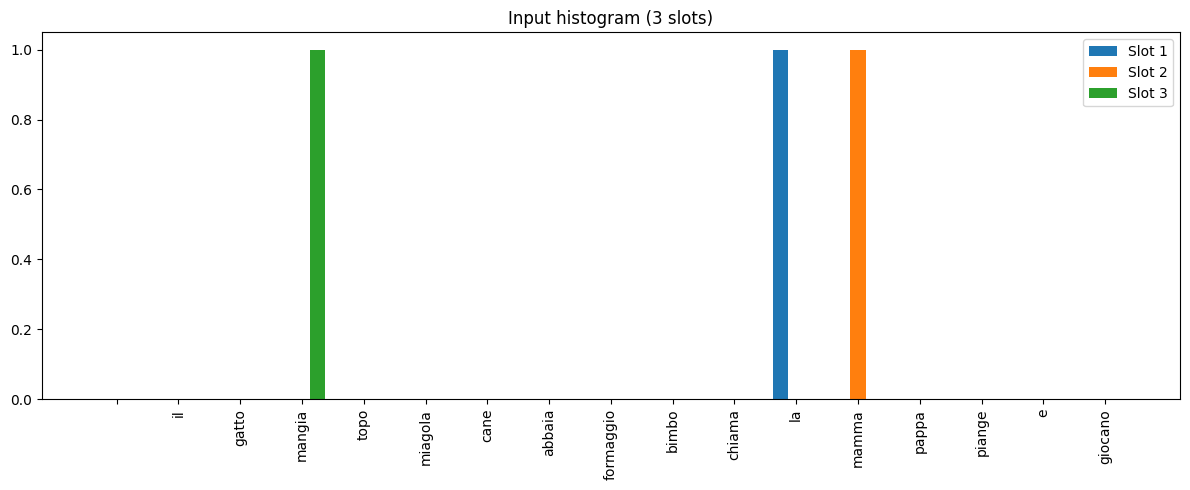

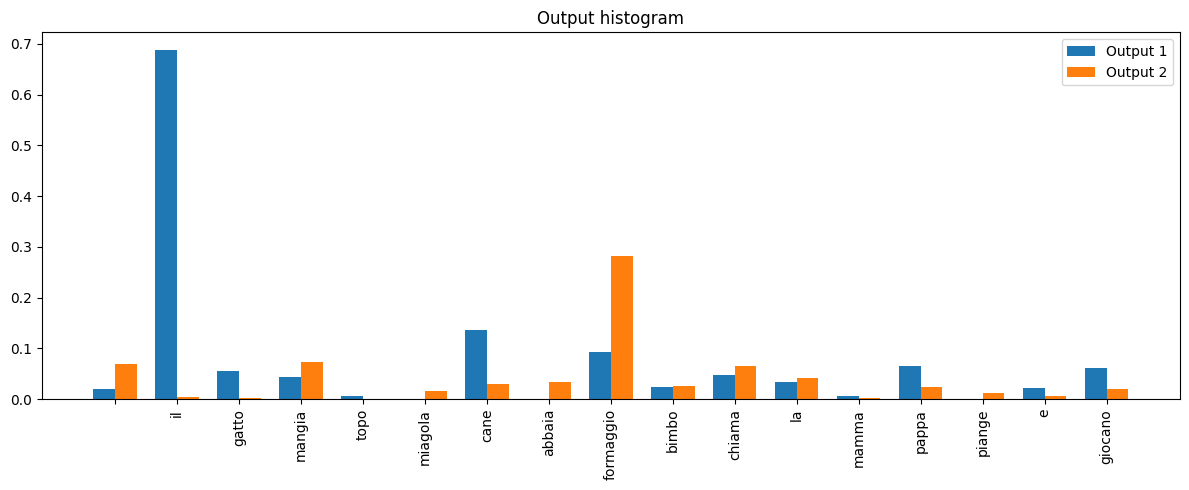

In [7]:
inOutExperiments("la","mamma","mangia")